<a href="https://colab.research.google.com/github/valceven/AliacSearchAlgo/blob/master/ISMiniCap3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()  # Upload your kaggle.json here

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ceven7","key":"55bac6f5322be9a379ab058260452d7e"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [15]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("chandrashekarnatesh/poultry-diseases")

# print("Path to dataset files:", path)

import os
os.listdir('../kaggle/input/poultry-diseases/data')

['data']

In [16]:
import os
from pathlib import Path

path = '../kaggle/input/poultry-diseases/data/data'

def count_images_in_folder(folder_path):
    total = 0
    for root, dirs, files in os.walk(folder_path):
        total += len([f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    return total

cocci_count = count_images_in_folder(os.path.join(path, "val/Coccidiosis"))
salmo_count = count_images_in_folder(os.path.join(path, "val/Salmonella"))
healthy_count = count_images_in_folder(os.path.join(path, "val/Healthy"))
newcastle_count = count_images_in_folder(os.path.join(path, "val/New Castle Disease"))

print(f"Cocci Images: {cocci_count}")
print(f"Salmo Images: {salmo_count}")
print(f"Healthy Images: {healthy_count}")
print(f"Newcastle Images: {newcastle_count}")

for folder in ["train", "val", "test"]:
    root_path = Path(path) / folder
    for ext in ['.JPG', '.JPEG']:
        for img_path in root_path.rglob(f'*{ext}'):
            img_path.rename(img_path.with_suffix(img_path.suffix.lower()))

Cocci Images: 10000
Salmo Images: 10000
Healthy Images: 10000
Newcastle Images: 10000


OSError: [Errno 30] Read-only file system: '../kaggle/input/poultry-diseases/data/data/train/Coccidiosis/cocci.741.jpg_aug28.JPG' -> '../kaggle/input/poultry-diseases/data/data/train/Coccidiosis/cocci.741.jpg_aug28.jpg'

In [17]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet_v2 import preprocess_input
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def preprocess_image(img, label):
    img = tf.keras.applications.resnet50.preprocess_input(img)
    return img, label

#os.listdir('../root/.cache/kagglehub/datasets/chandrashekarnatesh/poultry-diseases/versions/3/data/data/train/Coccidiosis')

In [18]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(path,"train"),
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
)
train_class_names = train_ds.class_names
num_batches = 40000 // BATCH_SIZE
train_ds = train_ds.take(num_batches)


test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(path,"test"),
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_class_names = test_ds.class_names
num_batches = 4000 // BATCH_SIZE
test_ds = test_ds.take(num_batches)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(path,"val"),
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

val_class_names = val_ds.class_names
num_batches = 4000 // BATCH_SIZE
val_ds = val_ds.take(num_batches)

Found 400000 files belonging to 4 classes.
Found 70677 files belonging to 4 classes.
Found 40000 files belonging to 4 classes.


In [19]:
train_ds = train_ds.map(preprocess_image)
val_ds = val_ds.map(preprocess_image)
test_ds = test_ds.map(preprocess_image)

print(len(train_ds))
print(len(test_ds))
print(len(val_ds))
# Define class names, should match the class order used during training
class_names = ["Coccidosis", "Newcastle", "Healthy", "Salmonella"]  # Example classes

# # Function to count occurrences of each class in the dataset
# def count_class_occurrences(dataset, class_names):
#     class_counts = {class_name: 0 for class_name in class_names}

#     for images, labels in dataset:
#         # Iterate through the batch and update counts based on class labels
#         for label in labels:
#             class_index = tf.argmax(label).numpy()  # Get the index of the max value in the one-hot label
#             class_name = class_names[class_index]
#             class_counts[class_name] += 1

#     return class_counts

# # Get the counts for train_ds
# train_class_counts = count_class_occurrences(train_ds, class_names)

# # Print the counts for each class in the training dataset
# print("Training Dataset Class Counts:")
# for class_name, count in train_class_counts.items():
#     print(f"{class_name}: {count}")


1250
125
125


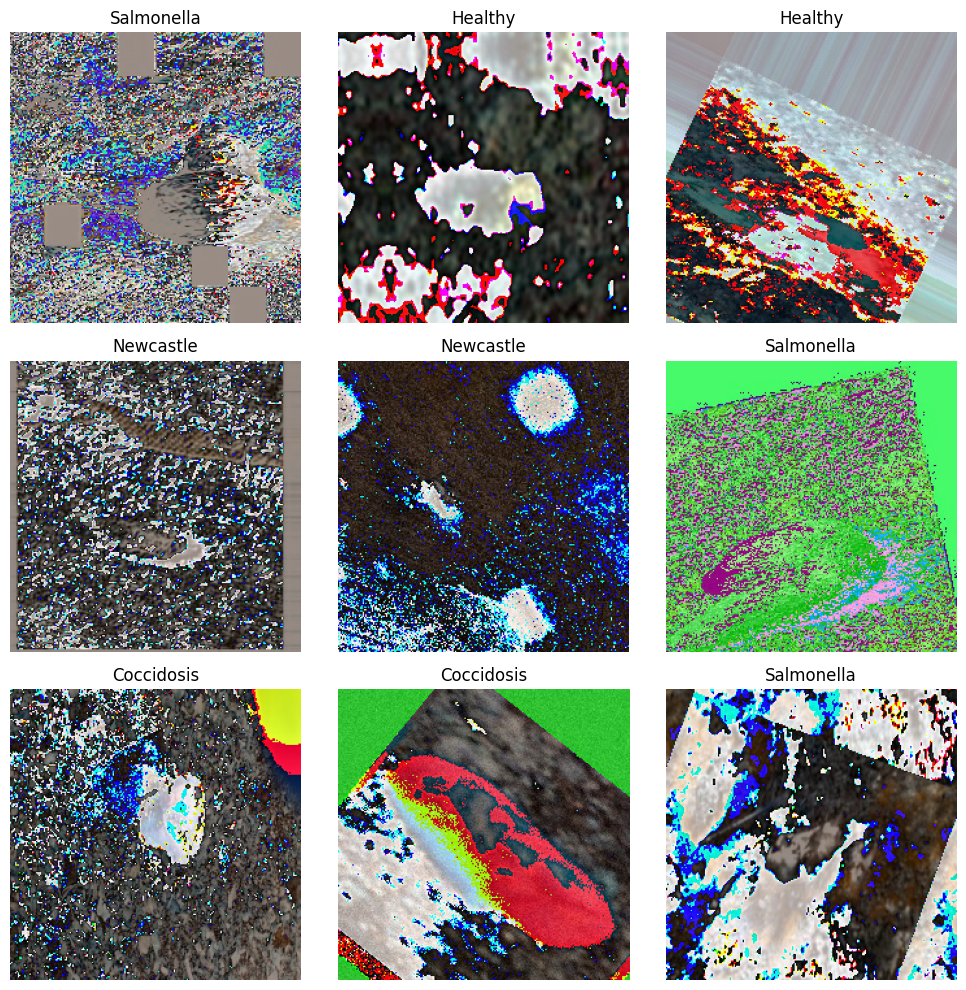

In [20]:
import matplotlib.pyplot as plt
import tensorflow as tf

# Show the first batch of images
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        label_index = tf.argmax(labels[i]).numpy()  # Assumes one-hot encoded labels
        plt.title(class_names[label_index])

        plt.axis("off")
    plt.tight_layout()
    plt.show()

In [21]:

from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

base_model = ResNet50V2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
)

base_model.trainable = True

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')
])


model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,835,588 (90.93 MB)

 Trainable params: 23,790,148 (90.75 MB)

 Non-trainable params: 45,440 (177.50 KB)

In [25]:

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=['accuracy']
)

model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[EarlyStopping(patience=3)]
)


Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 376s 263ms/step - accuracy: 0.9193 - loss: 0.2258 - val_accuracy: 0.8845 - val_loss: 0.3361
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 349s 252ms/step - accuracy: 0.9376 - loss: 0.1755 - val_accuracy: 0.8850 - val_loss: 0.3618
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 326s 256ms/step - accuracy: 0.9499 - loss: 0.1430 - val_accuracy: 0.8838 - val_loss: 0.3850
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 319s 253ms/step - accuracy: 0.9581 - loss: 0.1192 - val_accuracy: 0.8815 - val_loss: 0.4118


In [26]:
model.evaluate(test_ds)

125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 83ms/step - accuracy: 0.8708 - loss: 0.4367


[0.43869516253471375, 0.8709999918937683]

In [27]:
model.save('preprocessed_image21.h5')
from google.colab import files
files.download("preprocessed_image21.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>